In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [6]:
V = 1  # value
F = 1  # sanction

Text(0.5, 1.0, 'Model-Task Success Rate Matrix')

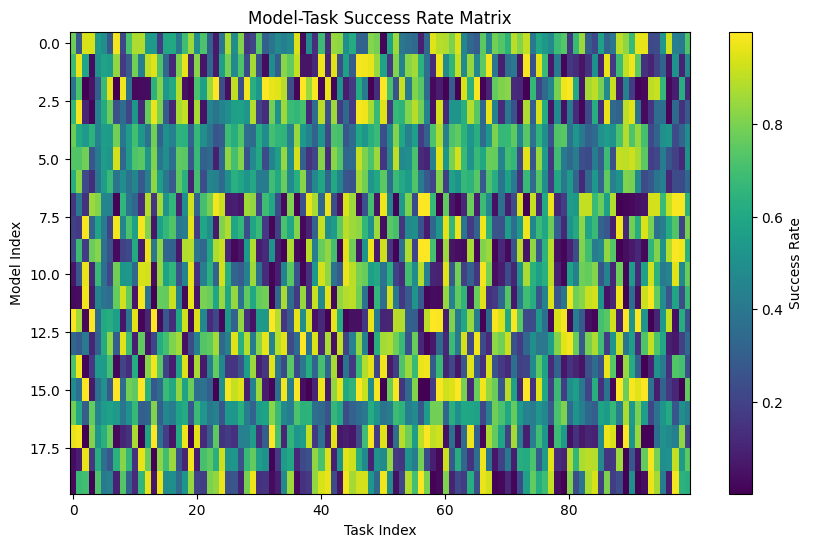

In [7]:
D = 4  # latent factors
N = 100  # tasks
M = 20  # models

# generate data
model_factors = np.random.randn(M, D) * 1
task_factors = np.random.randn(N, D) * 1

model_skill = np.random.randn(M) * 1e-1
model_cost = np.random.uniform(0, 1, M)

success_logits = model_factors @ task_factors.T + model_skill[:, None]
success_probs = 1 / (1 + np.exp(-success_logits))

bids = model_cost[:, None] + (1 - success_probs) * F

plt.figure(figsize=(10, 6))
plt.imshow(success_probs, aspect='auto', cmap='viridis')
plt.colorbar(label='Success Rate')
plt.xlabel('Task Index')
plt.ylabel('Model Index')
plt.title('Model-Task Success Rate Matrix') 

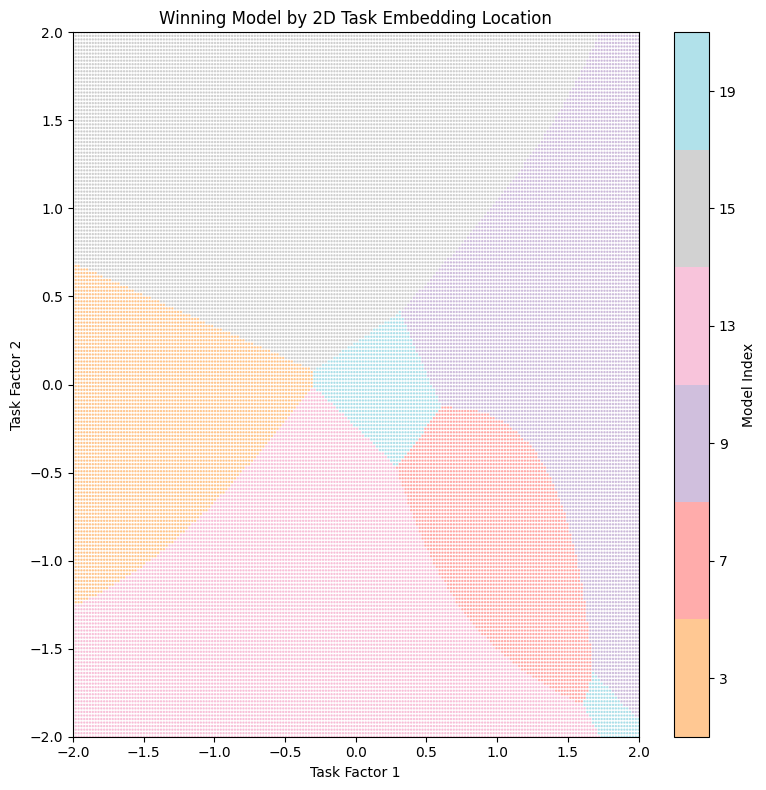

In [16]:
# Plot in 2D task space (-1, 1)-box which model is best at each point

xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
task_grid = np.stack([xx.ravel(), yy.ravel()], axis=1)  # shape: (num_points, 2)

# For each point, compute the logits/prob of each model
tasks = np.concatenate([task_grid, np.zeros((task_grid.shape[0], 2))], axis=1)
logits_grid = model_factors @ tasks.T + model_skill[:, None]  # shape: (M, num_points)
success_probs_grid = 1 / (1 + np.exp(-logits_grid))  # shape: (M, num_points)
bids_grid = model_cost[:, None] + (1 - success_probs_grid) * F

# Find best model at each grid point
best_model_idx = np.argmin(bids_grid, axis=0)  # (num_points,)
winning_models = np.unique(best_model_idx)  # only models that win somewhere

# Map to discrete colormap with only winning model colors (no unused colors)
from matplotlib.colors import ListedColormap
cmap = plt.cm.tab20
winning_colors = [cmap(i % 20) for i in winning_models]
cmap_discrete = ListedColormap(winning_colors)
model_to_idx = {m: i for i, m in enumerate(winning_models)}
c_mapped = np.array([model_to_idx[m] for m in best_model_idx])

# Plot
plt.figure(figsize=(8, 8))
scatter = plt.scatter(task_grid[:,0], task_grid[:,1], c=c_mapped, cmap=cmap_discrete, vmin=-0.5, vmax=len(winning_models)-0.5, marker='.', alpha=0.8, s=2)
plt.xlabel('Task Factor 1')
plt.ylabel('Task Factor 2')
plt.title("Winning Model by 2D Task Embedding Location")
cb = plt.colorbar(scatter, ticks=range(len(winning_models)), label="Model Index")
cb.ax.set_yticklabels(winning_models)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

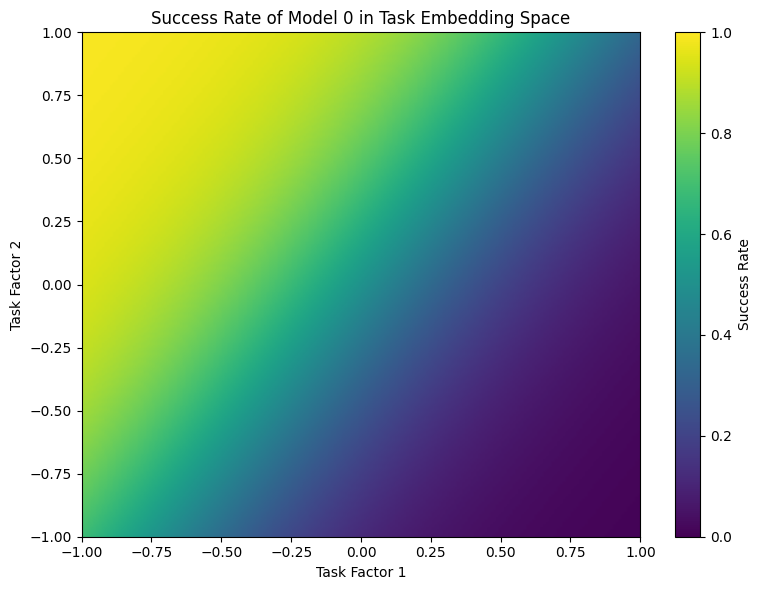

In [17]:
# Plot the success rate of model 0 across the 2D task space

# Compute success probabilities for model 0 in the task grid
success_rate_model1 = success_probs_grid[1]  # shape: (num_points,)

# Reshape to (200, 200) for plotting over the grid
success_rate_model1_grid = success_rate_model1.reshape(xx.shape)

plt.figure(figsize=(8, 6))
im = plt.imshow(
    success_rate_model1_grid,
    origin='lower',
    extent=[-1, 1, -1, 1],
    vmin=0,
    vmax=1,
    cmap='viridis',
    aspect='auto'
)
plt.colorbar(im, label='Success Rate')
plt.xlabel('Task Factor 1')
plt.ylabel('Task Factor 2')
plt.title('Success Rate of Model 0 in Task Embedding Space')
plt.tight_layout()
plt.show()

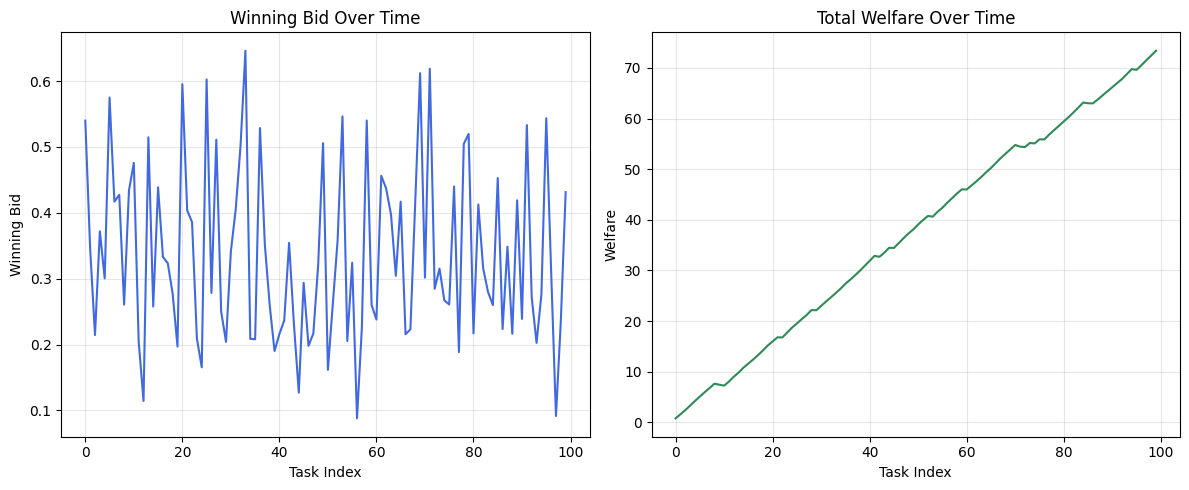

In [18]:
winner = np.argmin(bids, axis=0)
winning_bid = bids[np.argsort(bids, axis=0)[1], np.arange(N)]
success_rate = success_probs[winner, np.arange(N)]
cost = model_cost[winner]

failure = np.random.binomial(1, 1 - success_rate)
welfare = V - failure * F - cost

# Plot winning bid and total welfare over time

plt.figure(figsize=(12, 5))

# Plot winning bid over time
plt.subplot(1, 2, 1)
plt.plot(winning_bid, color='royalblue')
plt.xlabel('Task Index')
plt.ylabel('Winning Bid')
plt.title('Winning Bid Over Time')
plt.grid(alpha=0.3)

# Plot total welfare over time
plt.subplot(1, 2, 2)
plt.plot(np.cumsum(welfare), color='seagreen')
plt.xlabel('Task Index')
plt.ylabel('Welfare')
plt.title('Total Welfare Over Time')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
task_auction_bids = model_cost[:, None] + (1 - success_probs) * F
task_auction_winners = np.argmin(task_auction_bids, axis=0)
task_auction_success_rates = success_probs[task_auction_winners, np.arange(N)]
task_auction_costs = model_cost[task_auction_winners]
task_auction_welfares = V - (1 - task_auction_success_rates) * F - task_auction_costs

avg_success_rate = np.mean(success_probs, axis=1)
auction_bids = model_cost + (1 - avg_success_rate) * F
auction_winners = np.argmin(auction_bids, axis=0)
auction_success_rates = success_probs[auction_winners, np.arange(N)]
auction_costs = model_cost[auction_winners]
auction_welfares = V - (1 - auction_success_rates) * F - auction_costs

values = V - (1 - success_probs) * F - model_cost[:, None]
oracle_welfare = np.max(values, axis=0)

(oracle_welfare.mean() / task_auction_welfares.mean()).item(), (oracle_welfare.mean() / auction_welfares.mean()).item()

(1.0, 1.714734273409758)

In [ ]:
from datasets import load_dataset
import os

tmp_dir = os.path.join("data", "openarena")

flat = {}
for fn in os.listdir(tmp_dir):
    if fn.endswith(".jsonl"):
        key = fn[:-len(".jsonl")].replace("__", "/")
        flat[key] = load_dataset("json", data_files={"train": os.path.join(tmp_dir, fn)}, split="train")

/opt/anaconda3/envs/tgv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
MIN_N_ITEMS = 3

def norm_name(s: str) -> str:
    return str(s).strip().strip("_").rstrip(".")

grouped = {}
for k, ds in flat.items():
    if len(set(ds["model"])) < MIN_N_ITEMS:
        print("SKIP small dataset", k, "with", len(set(ds["model"])), "models", flush=True)
        continue
    k = str(k).strip()
    raw_bench = k.split("_", 1)[0]
    bench = norm_name(raw_bench)
    raw_section = k[len(raw_bench):].lstrip("_")
    section = norm_name(raw_section) or bench
    grouped.setdefault(bench, {})[section] = ds

SKIP small dataset gsm8k with 1 models
SKIP small dataset bbh_cot_fewshot_logical_deduction_three_objects with 1 models
SKIP small dataset bbh_cot_fewshot_multistep_arithmetic_two with 1 models
SKIP small dataset bbh_cot_fewshot_sports_understanding with 1 models
SKIP small dataset bbh_cot_fewshot_tracking_shuffled_objects_five_objects with 1 models
SKIP small dataset bbh_cot_fewshot_salient_translation_error_detection with 1 models
SKIP small dataset bbh_cot_fewshot_boolean_expressions with 1 models
SKIP small dataset bbh_cot_fewshot_date_understanding with 1 models
SKIP small dataset bbh_cot_fewshot_web_of_lies with 1 models
SKIP small dataset minerva_math_num_theory with 2 models
SKIP small dataset bbh_cot_fewshot_geometric_shapes with 1 models
SKIP small dataset bbh_dyck_languages with 2 models
SKIP small dataset bbh_cot_fewshot_disambiguation_qa with 1 models
SKIP small dataset bbh_cot_fewshot_logical_deduction_five_objects with 1 models
SKIP small dataset bbh_cot_fewshot_tracking

In [22]:
grouped.keys()

dict_keys(['bbh', 'math', 'musr', 'gpqa', 'arc', 'ifeval', 'mmlu'])

In [42]:
for group, datasets in grouped.items():
    print(group)
    for dataset, ds in datasets.items():
        print(f"  {dataset}: {len(ds)}")
        uniq_models = len(set(ds["model"]))
        print(f"    {uniq_models} unique models")
        uniq_tasks = len(set(ds["tid"]))
        print(f"    {uniq_tasks} unique tasks")

        uniq_model_tasks = len(set(zip(ds["model"], ds["tid"])))
        print(f"    {uniq_model_tasks} unique model-task pairs")
        print(f"    {(uniq_model_tasks / (uniq_models * uniq_tasks)):.2%} Coverage")


bbh
  fewshot_ruin_names: 710
    5 unique models
    250 unique tasks
    710 unique model-task pairs
    56.80% Coverage
  formal_fallacies: 25500
    99 unique models
    250 unique tasks
    24750 unique model-task pairs
    100.00% Coverage
  fewshot_boolean_expressions: 710
    5 unique models
    250 unique tasks
    710 unique model-task pairs
    56.80% Coverage
  fewshot_geometric_shapes: 710
    5 unique models
    250 unique tasks
    710 unique model-task pairs
    56.80% Coverage
  movie_recommendation: 25500
    99 unique models
    251 unique tasks
    24752 unique model-task pairs
    99.61% Coverage
  fewshot_hyperbaton: 710
    5 unique models
    250 unique tasks
    710 unique model-task pairs
    56.80% Coverage
  disambiguation_qa: 25500
    99 unique models
    250 unique tasks
    24750 unique model-task pairs
    100.00% Coverage
  tracking_shuffled_objects_three_objects: 25500
    99 unique models
    250 unique tasks
    24750 unique model-task pairs
    100

In [43]:
grouped['math'].keys()

dict_keys(['math', 'num_theory', 'counting_and_prob_hard', 'num_theory_hard', 'algebra', 'precalculus_hard', 'intermediate_algebra_hard', 'prealgebra_hard', 'precalculus', 'algebra_hard', 'intermediate_algebra', 'geometry_hard', 'geometry', 'counting_and_prob', 'prealgebra'])

In [ ]:
# Task model fit on real data: d=2 (same as synthetic), PyTorch + LBFGS
import numpy as np
import pandas as pd
import torch

math_datasets = list(grouped['math'].values())
dfs = [(category, ds.to_pandas()) for category, ds in grouped['math'].items()]
dfs = [df.assign(category=category) for category, df in dfs]
df = pd.concat(dfs, ignore_index=True)
df = df.drop_duplicates(subset=['tid', 'model']).reset_index(drop=True)

# p(correct | model, task) = sigmoid(skill[model] + model_factors[model] @ task_factors[task])
REG = 1e-2
D=2

categories = sorted(df['category'].unique())
models = sorted(df['model'].unique())
tasks = sorted(df['tid'].unique())
category_idx = {c: i for i, c in enumerate(categories)}
model_idx = {m: i for i, m in enumerate(models)}
task_idx = {t: i for i, t in enumerate(tasks)}

C, M, N = len(categories), len(models), len(tasks)
print(f"C={C}, M={M}, N={N}")

categories = np.full((M, N), np.nan)
for _, row in df.iterrows():
    categories[model_idx[row['model']], task_idx[row['tid']]] = category_idx[row['category']]

outcomes = np.full((M, N), np.nan)
for _, row in df.iterrows():
    outcomes[model_idx[row['model']], task_idx[row['tid']]] = int(row['correct'])

mask = ~np.isnan(outcomes)
obs_c = torch.tensor(categories[mask], dtype=torch.float32)
obs_m = np.where(mask)[0]
obs_t = np.where(mask)[1]
outcomes_obs = torch.tensor(outcomes[mask], dtype=torch.float32)

model_skill = torch.nn.Parameter(torch.zeros(M))
model_factors = torch.nn.Parameter(torch.randn(M, D) * 0.1)
task_factors = torch.nn.Parameter(torch.randn(N, D) * 0.1)
optimizer = torch.optim.LBFGS([model_skill, model_factors, task_factors], lr=1e-1, max_iter=10000, tolerance_grad=1e-6)

def closure():
    optimizer.zero_grad()
    logits_obs = model_skill[obs_m] + (model_factors[obs_m] * task_factors[obs_t]).sum(dim=1)
    pred_obs = torch.sigmoid(logits_obs)
    loss = ((pred_obs - outcomes_obs) ** 2).mean()
    loss += REG * (model_skill ** 2).mean() + REG * (model_factors ** 2).mean() + REG * (task_factors ** 2).mean()
    loss.backward()
    return loss

optimizer.step(closure)
with torch.no_grad():
    logits_obs = model_skill[obs_m] + (model_factors[obs_m] * task_factors[obs_t]).sum(dim=1)
    pred_obs = torch.sigmoid(logits_obs)
    loss = ((pred_obs - outcomes_obs) ** 2).mean()
print(f"Loss: {loss.item():.4f}")

print("Model skills:", dict(zip(models, model_skill.detach().numpy().tolist())))
print("Model factors:", {m: model_factors.detach().numpy()[i].tolist() for i, m in enumerate(models)})
print("Sample task factors (first 5):", task_factors.detach().numpy()[:5])

C=15, M=99, N=7841
Loss: 0.0329
Model skills: {'EleutherAI__gpt-j-6b': -0.28635549545288086, 'EleutherAI__gpt-neo-125m': -0.5382350087165833, 'EleutherAI__gpt-neox-20b': -0.2883508801460266, 'EleutherAI__pythia-160m': -0.3151456117630005, 'HuggingFaceTB__SmolLM-135M': -0.5299344062805176, 'HuggingFaceTB__SmolLM-135M-Instruct': -0.3189777731895447, 'HuggingFaceTB__SmolLM2-1.7B-Instruct': -0.1959702968597412, 'HuggingFaceTB__SmolLM2-135M': -0.5453226566314697, 'HuggingFaceTB__SmolLM2-135M-Instruct': -0.3138198256492615, 'HuggingFaceTB__SmolLM2-360M-Instruct': -0.3047220706939697, 'LGAI-EXAONE__EXAONE-3.5-2.4B-Instruct': -0.26913532614707947, 'LGAI-EXAONE__EXAONE-3.5-7.8B-Instruct': -0.329916387796402, 'NousResearch__Hermes-3-Llama-3.2-3B': -0.23655357956886292, 'Qwen__Qwen2-0.5B': -0.2351936399936676, 'Qwen__Qwen2-0.5B-Instruct': -0.28487715125083923, 'Qwen__Qwen2-1.5B': -0.15563935041427612, 'Qwen__Qwen2-1.5B-Instruct': -0.15914452075958252, 'Qwen__Qwen2-7B-Instruct': -0.174652636051177

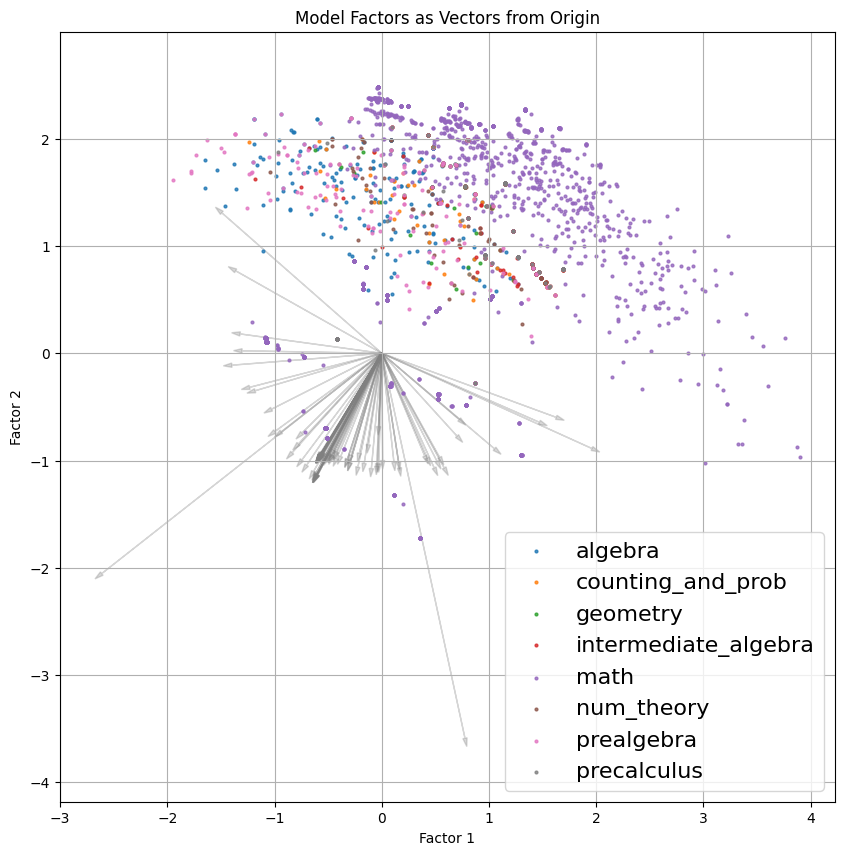

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i, m in enumerate(models):
    plt.arrow(
        0, 0,
        model_factors[i, 0].item(), model_factors[i, 1].item(),
        head_width=0.04, head_length=0.08, 
        length_includes_head=True,
        color='gray',
        alpha=0.3,
        label=None  # Don't use label in arrow; we'll handle legend separately
    )

plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Model Factors as Vectors from Origin')
plt.grid(True)
plt.axis('equal')

# Plot tasks as points, colored by category prefix (geometry_hard same as geometry)
task_categories = df.groupby('tid')['category'].first()
# Prefix = strip "_hard" so geometry_hard and geometry share the same color
def get_prefix(cat):
    return cat.replace("_hard", "") if cat.endswith("_hard") else cat
prefixes = sorted(set(get_prefix(c) for c in task_categories.values))
prefix_idx = {p: i for i, p in enumerate(prefixes)}
task_prefix_idx = np.array([prefix_idx[get_prefix(task_categories[t])] for t in tasks])
tf = task_factors[:, 0].detach().numpy(), task_factors[:, 1].detach().numpy()
cmap = plt.cm.tab10
for i, prefix in enumerate(prefixes):
    mask = task_prefix_idx == i
    plt.scatter(tf[0][mask], tf[1][mask], c=[cmap(i % 10)], alpha=0.8, label=prefix, s=4)
plt.legend(loc='best', fontsize=16)
plt.show()

Train: 117476, Test: 29370 observations
Accuracy by dimension (columns) and regularization (rows):
REG \ D:     1      2      3      4      5      6      8     10
 1e+00  0.929 0.929 0.929 0.929 0.929 0.929 0.929 0.929
 1e-01  0.929 0.929 0.935 0.938 0.940 0.940 0.938 0.936
 1e-02  0.936 0.939 0.936 0.936 0.932 0.929 0.924 0.923
 1e-03  0.938 0.936 0.931 0.925 0.923 0.917 0.914 0.917
 1e-04  0.937 0.930 0.782 0.922 0.896 0.902 0.906 0.914


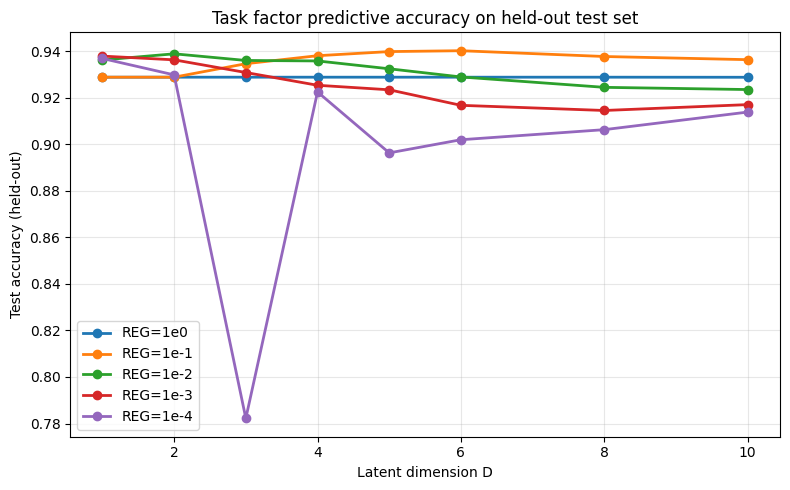

In [ ]:
# Task factor predictive accuracy on held-out test set over dimension
import numpy as np
import torch
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

# Split observations into train (80%) and test (20%)
n_obs = len(obs_m)
idx = np.arange(n_obs)
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

obs_m_train, obs_m_test = obs_m[train_idx], obs_m[test_idx]
obs_t_train, obs_t_test = obs_t[train_idx], obs_t[test_idx]
outcomes_train = outcomes_obs[train_idx]
outcomes_test = outcomes_obs[test_idx]
print(f"Train: {len(train_idx)}, Test: {len(test_idx)} observations")

dims = [1, 2, 3, 4, 5, 6, 8, 10]
reg_levels = [1e0, 1e-1, 1e-2, 1e-3, 1e-4]
all_results = {}

for REG in reg_levels:
    accuracies = []
    for D_fit in dims:
        if D_fit > min(M, N):
            accuracies.append(np.nan)
            continue
        model_skill = torch.nn.Parameter(torch.zeros(M))
        model_factors = torch.nn.Parameter(torch.randn(M, D_fit) * 0.1)
        task_factors = torch.nn.Parameter(torch.randn(N, D_fit) * 0.1)
        optimizer = torch.optim.LBFGS([model_skill, model_factors, task_factors], lr=1e-1, max_iter=10000, tolerance_grad=1e-6)

        def closure():
            optimizer.zero_grad()
            logits = model_skill[obs_m_train] + (model_factors[obs_m_train] * task_factors[obs_t_train]).sum(dim=1)
            pred = torch.sigmoid(logits)
            loss = ((pred - outcomes_train) ** 2).mean()
            loss += REG * (model_skill ** 2).mean() + REG * (model_factors ** 2).mean() + REG * (task_factors ** 2).mean()
            loss.backward()
            return loss

        optimizer.step(closure)

        with torch.no_grad():
            logits_test = model_skill[obs_m_test] + (model_factors[obs_m_test] * task_factors[obs_t_test]).sum(dim=1)
            pred_test = torch.sigmoid(logits_test)
            acc = ((pred_test > 0.5).float() == outcomes_test).float().mean().item()
        accuracies.append(acc)
    all_results[REG] = accuracies

# Print overlaid results
print("Accuracy by dimension (columns) and regularization (rows):")
print("REG \\ D:", "  ".join(f"{d:>5}" for d in dims))
for REG in reg_levels:
    row = " ".join(f"{a:>5.3f}" if not np.isnan(a) else "   N/A" for a in all_results[REG])
    print(f"{REG:>6.0e}  {row}")

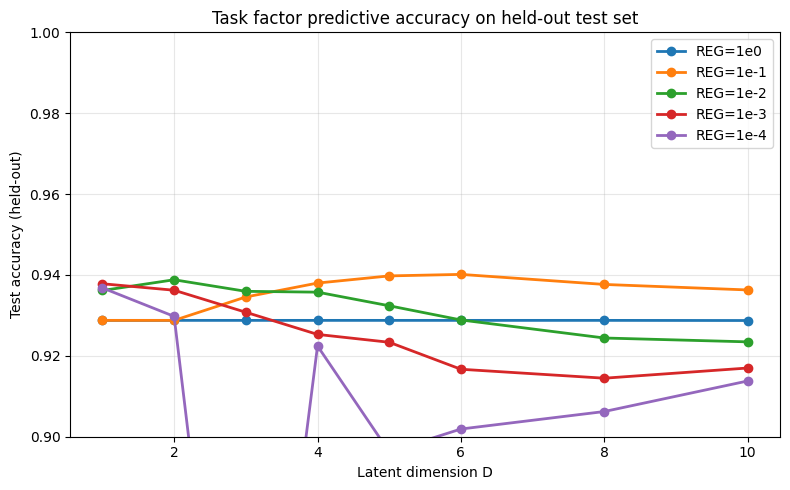

In [40]:
# Plot overlaid
plt.figure(figsize=(8, 5))
for REG in reg_levels:
    accs = all_results[REG]
    valid = ~np.isnan(accs)
    exp = int(np.log10(REG))
    label = f"REG=1e{exp}" if exp != 0 else "REG=1e0"
    plt.plot(np.array(dims)[valid], np.array(accs)[valid], 'o-', linewidth=2, markersize=6, label=label)
plt.xlabel('Latent dimension D')
plt.ylabel('Test accuracy (held-out)')
plt.title('Task factor predictive accuracy on held-out test set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0.9,1.0)
plt.show()

In [25]:
print('\n'.join(models))

EleutherAI__gpt-j-6b
EleutherAI__gpt-neo-125m
EleutherAI__gpt-neox-20b
EleutherAI__pythia-160m
HuggingFaceTB__SmolLM-135M
HuggingFaceTB__SmolLM-135M-Instruct
HuggingFaceTB__SmolLM2-1.7B-Instruct
HuggingFaceTB__SmolLM2-135M
HuggingFaceTB__SmolLM2-135M-Instruct
HuggingFaceTB__SmolLM2-360M-Instruct
LGAI-EXAONE__EXAONE-3.5-2.4B-Instruct
LGAI-EXAONE__EXAONE-3.5-7.8B-Instruct
NousResearch__Hermes-3-Llama-3.2-3B
Qwen__Qwen2-0.5B
Qwen__Qwen2-0.5B-Instruct
Qwen__Qwen2-1.5B
Qwen__Qwen2-1.5B-Instruct
Qwen__Qwen2-7B-Instruct
Qwen__Qwen2-VL-7B-Instruct
Qwen__Qwen2.5-0.5B
Qwen__Qwen2.5-0.5B-Instruct
Qwen__Qwen2.5-1.5B
Qwen__Qwen2.5-1.5B-Instruct
Qwen__Qwen2.5-14B-Instruct
Qwen__Qwen2.5-32B
Qwen__Qwen2.5-32B-Instruct
Qwen__Qwen2.5-3B
Qwen__Qwen2.5-3B-Instruct
Qwen__Qwen2.5-72B-Instruct
Qwen__Qwen2.5-7B
Qwen__Qwen2.5-7B-Instruct
Qwen__Qwen2.5-Coder-14B-Instruct
Qwen__Qwen2.5-Coder-32B-Instruct
Qwen__Qwen2.5-Coder-7B
Qwen__Qwen2.5-Coder-7B-Instruct
Qwen__Qwen2.5-Math-7B-Instruct
TinyLlama__TinyLlama-1.

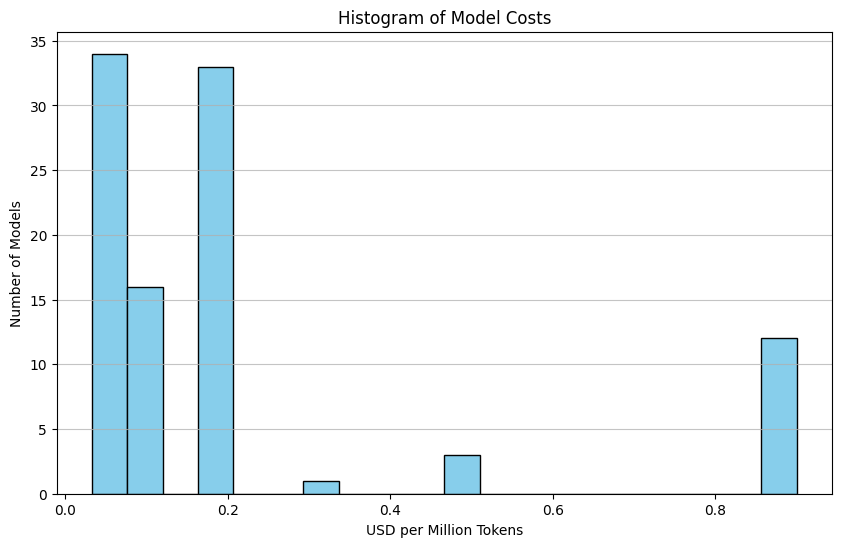

In [ ]:
import json

model_costs = {}
f_model_costs = os.path.join("data", "model_costs.jsonl")
with open(f_model_costs, 'r') as f:
    for line in f:
        data = json.loads(line)
        model_costs[data['model']] = data['usd_per_million_tokens']

model_costs = np.array([model_costs[m] for m in models])

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(model_costs, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('USD per Million Tokens')
plt.ylabel('Number of Models')
plt.title('Histogram of Model Costs')
plt.grid(axis='y', alpha=0.75)
plt.show()


Text(0.5, 1.0, 'Model-Task Success Rate Matrix')

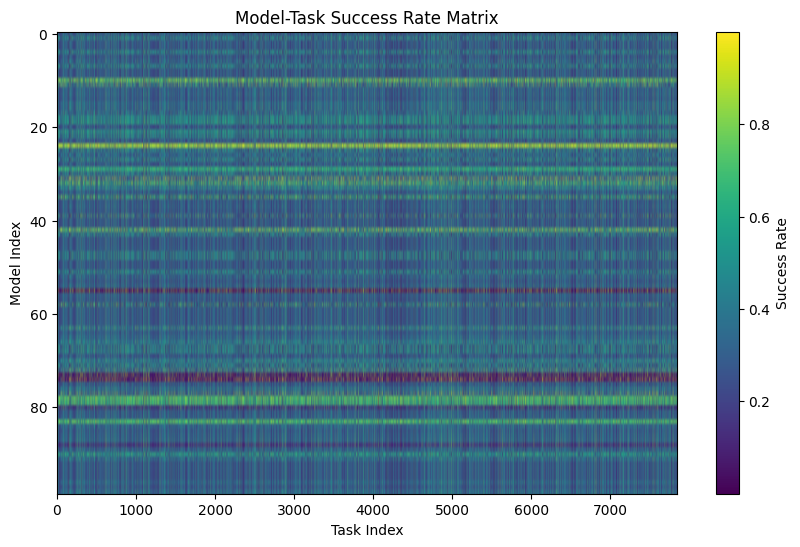

In [27]:
model_factors = model_factors.detach().numpy()
task_factors = task_factors.detach().numpy()
model_skill = model_skill.detach().numpy()
model_cost = model_costs

success_logits = model_factors @ task_factors.T + model_skill[:, None]
success_probs = 1 / (1 + np.exp(-success_logits))

bids = model_cost[:, None] + (1 - success_probs) * F

plt.figure(figsize=(10, 6))
plt.imshow(success_probs, aspect='auto', cmap='viridis')
plt.colorbar(label='Success Rate')
plt.xlabel('Task Index')
plt.ylabel('Model Index')
plt.title('Model-Task Success Rate Matrix') 

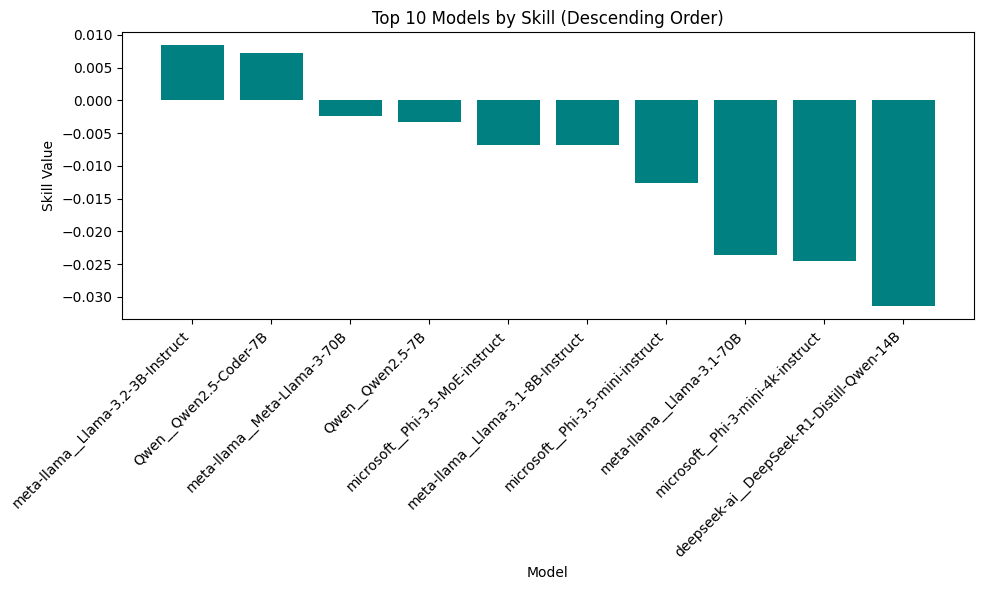

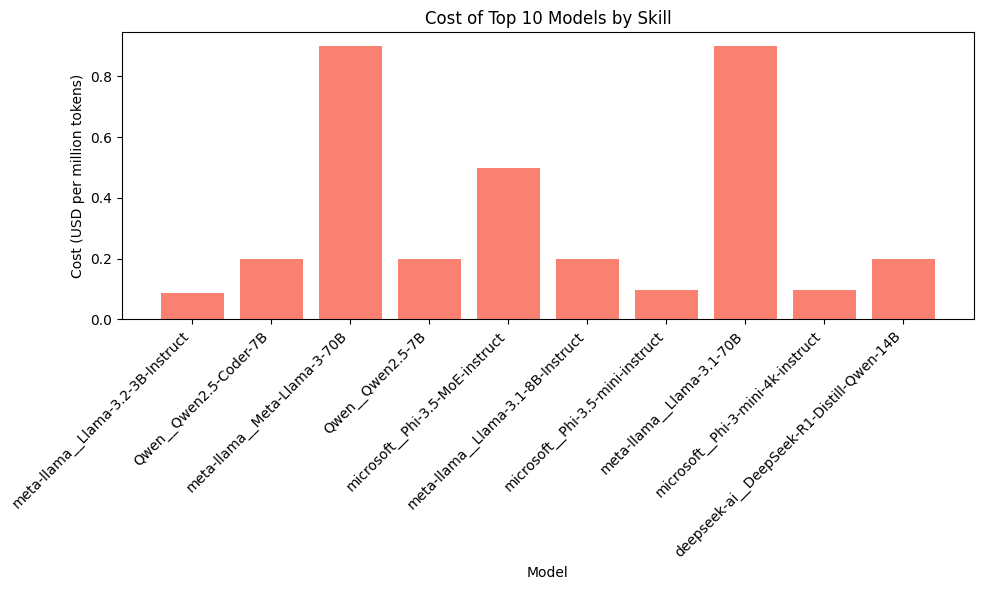

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Find the indices of the 10 models with the highest skill
top_n = 10
top_skill_indices = np.argsort(model_skill.flatten())[::-1][:top_n]

# Get corresponding skills, model names, and costs
top_skills = model_skill.flatten()[top_skill_indices]
top_models = np.array(models)[top_skill_indices]
top_costs = model_cost.flatten()[top_skill_indices]

# Plot bar chart for top 10 model skills
plt.figure(figsize=(10, 6))
plt.bar(range(top_n), top_skills, color='teal')
plt.xticks(range(top_n), top_models, rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Skill Value')
plt.title('Top 10 Models by Skill (Descending Order)')
plt.tight_layout()
plt.show()

# Plot bar chart for costs of the top 10 skilled models
plt.figure(figsize=(10, 6))
plt.bar(range(top_n), top_costs, color='salmon')
plt.xticks(range(top_n), top_models, rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Cost (USD per million tokens)')
plt.title('Cost of Top 10 Models by Skill')
plt.tight_layout()
plt.show()

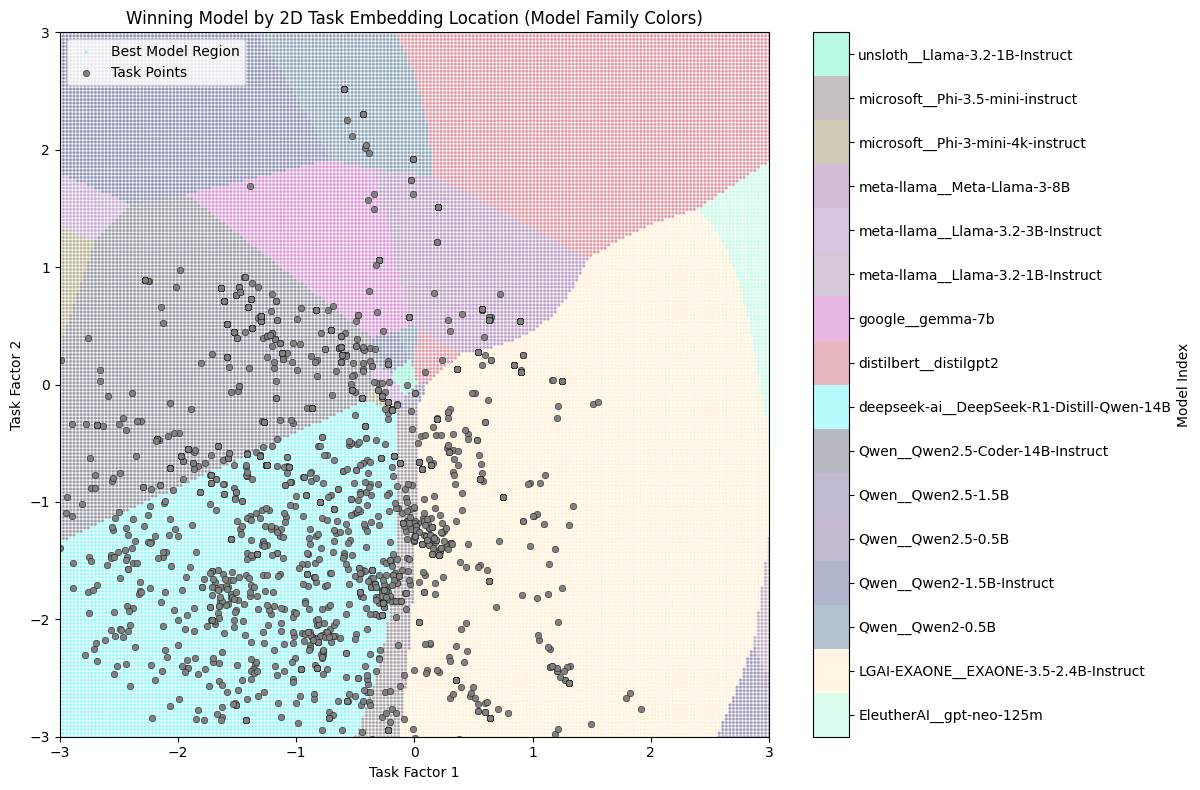

In [30]:
import hashlib

# Plot in 2D task space (-1, 1)-box which model is best at each point

# Setup a grid in task space [-1, 1] x [-1, 1]
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
task_grid = np.stack([xx.ravel(), yy.ravel()], axis=1)  # shape: (num_points, 2)

# For each point, compute the logits/prob of each model
# For synthetic plot, set task_difficulty=0 to focus on spatial factors
tasks = np.concatenate([task_grid, np.zeros((task_grid.shape[0], D-2))], axis=1)
logits_grid = model_factors @ tasks.T + model_skill[:, None]  # shape: (M, num_points)
success_probs_grid = 1 / (1 + np.exp(-logits_grid))  # shape: (M, num_points)
bids_grid = model_cost[:, None] + (1 - success_probs_grid) * F

# Find best model at each grid point
best_model_idx = np.argmin(bids_grid, axis=0)  # (num_points,)
winning_models = np.unique(best_model_idx)  # only models that win somewhere

def string_to_rgb(s):
    """Simplified: Hash base name of string into an RGB tuple (0-1 scale)."""
    name = s.lower()
    family = name.split('__')[0]
    # s_base = ''.join(c if c.isalnum() else ' ' for c in s_base).split()[0]
    h = hashlib.md5(family.encode('utf-8')).digest()
    rgb = tuple(0.2 + (x/255.0)*0.8 for x in h[:3])
    # randomly perturb rgb values
    rgb = tuple(x + np.random.uniform(-0.1, 0.1) for x in rgb)
    return rgb

# Generate color for each unique core model type
model_color_map = {}
for m in models:
    model_color_map[m] = string_to_rgb(m)

# For the winning models, gather their color
winning_colors_custom = [model_color_map[models[m]] for m in winning_models]
cmap_discrete_custom = ListedColormap(winning_colors_custom)

# Map each model index to a color index for the grid
model_to_idx_custom = {m: i for i, m in enumerate(winning_models)}
c_mapped_custom = np.array([model_to_idx_custom[m] for m in best_model_idx])

plt.figure(figsize=(12, 8))

# Plot the grid with the discrete colormap (background)
scatter = plt.scatter(
    task_grid[:,0], task_grid[:,1],
    c=c_mapped_custom,
    cmap=cmap_discrete_custom,
    vmin=-0.5,
    vmax=len(winning_models)-0.5,
    marker='.',
    alpha=0.4,
    s=8,
    label="Best Model Region"
)

# Overlay the task points (foreground)
plt.scatter(
    task_factors[:,0], task_factors[:,1],
    c='gray',
    alpha=1,
    s=22,
    edgecolor='black',
    linewidth=0.3,
    label="Task Points"
)

plt.xlabel('Task Factor 1')
plt.ylabel('Task Factor 2')
plt.title("Winning Model by 2D Task Embedding Location (Model Family Colors)")

cb = plt.colorbar(scatter, ticks=range(len(winning_models)), label="Model Index")
cb.ax.set_yticklabels([models[m] for m in winning_models])

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()



In [31]:
task_auction_bids = model_cost[:, None] + (1 - success_probs) * F
task_auction_winners = np.argmin(task_auction_bids, axis=0)
task_auction_success_rates = success_probs[task_auction_winners, np.arange(N)]
task_auction_costs = model_cost[task_auction_winners]
task_auction_welfares = V - (1 - task_auction_success_rates) * F - task_auction_costs

avg_success_rate = np.mean(success_probs, axis=1)
auction_bids = model_cost + (1 - avg_success_rate) * F
auction_winners = np.argmin(auction_bids, axis=0)
print(models[auction_winners])
auction_success_rates = success_probs[auction_winners, np.arange(N)]
auction_costs = model_cost[auction_winners]
auction_welfares = V - (1 - auction_success_rates) * F - auction_costs

values = V - (1 - success_probs) * F - model_cost[:, None]
oracle_welfare = np.max(values, axis=0)

(oracle_welfare.mean() / task_auction_welfares.mean()).item(), (oracle_welfare.mean() / auction_welfares.mean()).item()

LGAI-EXAONE__EXAONE-3.5-2.4B-Instruct


(1.0, 1.4451513557321087)

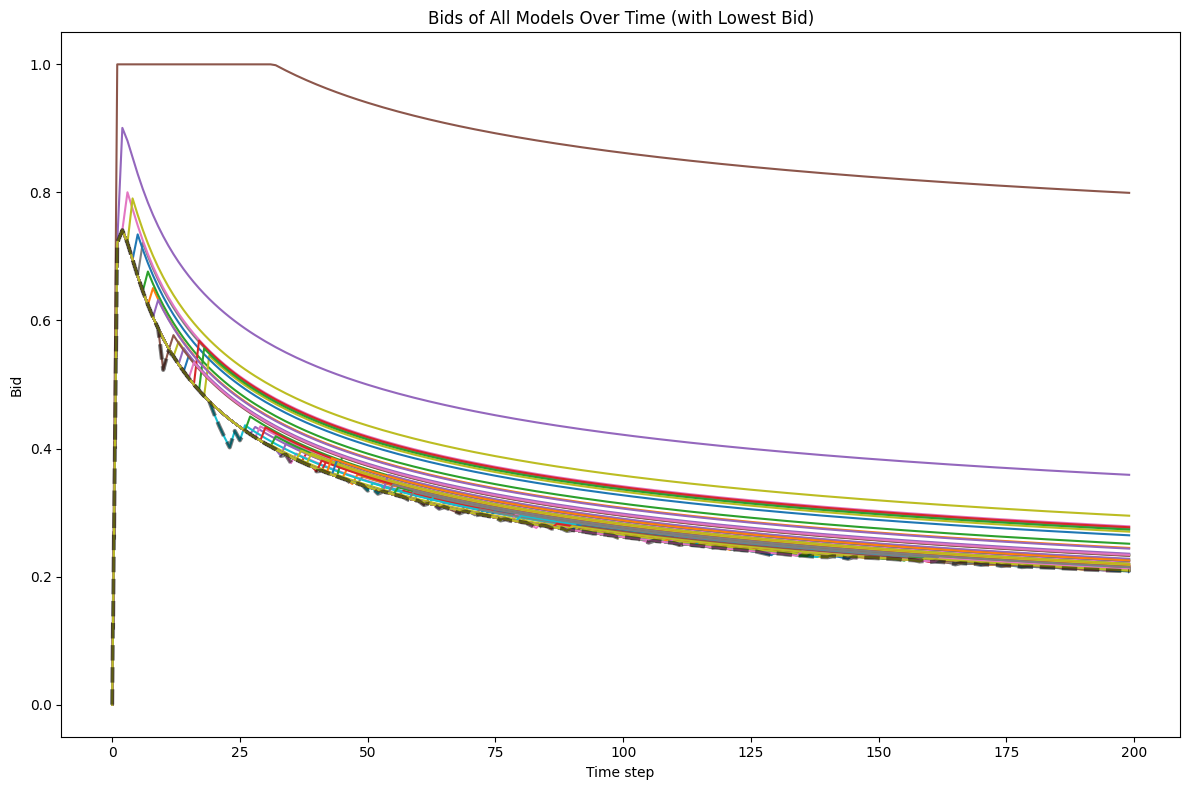

In [32]:
import matplotlib.pyplot as plt

T = 200

w = 1
b = np.zeros(M)
c = np.zeros(M)

bids = np.zeros((T, M))
for t in range(T):
    bt = np.minimum(1, c + np.sqrt((3 * np.log(t+1)) / (2 * w)))
    best_bid = np.min(bt)
    winners = np.where(bt == best_bid)[0]
    winner = np.random.choice(winners)

    price = np.sort(bt)[1]
    cost = model_cost[winner]
    success = np.random.binomial(1, success_probs[winner, t])
    ct = cost + (1 - success) * F - price
    c[winner] = (w * c[winner] + ct) / (w + 1)

    bids[t] = bt
    w += 1

plt.figure(figsize=(12, 8))
for m in range(M):
    plt.plot(bids[:, m], label=f"Model {models[m]}" if 'models' in locals() else f"Model {m}")

# Add a dashed line showing the lowest bid at each timestep
lowest_bids = np.min(bids, axis=1)
plt.plot(lowest_bids, 'k--', label="Lowest Bid Each Timestep", linewidth=3, alpha=0.5)

plt.xlabel("Time step")
plt.ylabel("Bid")
plt.title("Bids of All Models Over Time (with Lowest Bid)")
plt.tight_layout()
plt.show()


In [ ]:
# future lines:
# - proof of convergence for multi-agent UCB-id
# - some sort of task-conditioned UCB-id (can we learn the factor model while still converging to optimal bids?)
# - contextual framework